# MRS Interactive Corridor Builder — v6 (Single Scroll + Tooltip‑free)

This notebook builds an interactive map to route **Station A → (optional VIAs) → Station B** on your rail network.

## Why v6
Your current `ipyleaflet` build cannot import `Tooltip`, so this notebook shows station names **always visible** using **`DivIcon` label markers** (supported broadly).

## Included features
- ✅ **Single scrollbar** for the whole left panel (no nested scrollbars in outputs).
- ✅ **Station deduplication across highlights** (A→B then B→C shows **B once**).
- ✅ Station names **always visible** under markers (DivIcon labels).
- ✅ Route distance shown in **status**, **output**, and **on the route**.
- ✅ **Remove selected** highlight or **Remove ALL**.
- ✅ **Save/Load highlights** to a JSON file.
- ✅ Polyline “shadow/wedge” fixed via **round** joins/caps.

> Tip: Best experience in **JupyterLab** (or VS Code notebooks) with ipywidgets enabled.


In [13]:
# (Optional) Install dependencies in THIS kernel environment.
# If you already have these installed, keep this cell commented.

# !pip -q install geopandas shapely pyproj networkx scipy ipyleaflet ipywidgets pandas


In [14]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json

import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx

from shapely.geometry import LineString, Point
from shapely.ops import unary_union, snap, nearest_points

from scipy.spatial import cKDTree
from pyproj import Transformer
import threading
import concurrent.futures

from ipyleaflet import (
    Map, GeoData, LayersControl, WidgetControl,
    Polyline, Marker, basemaps,
    DivIcon
)
import ipywidgets as widgets

print('Imports OK (Tooltip-free)')


Imports OK (Tooltip-free)


In [15]:
# -------------------------
# 1) Configuration
# -------------------------

RAILS_SHP_PATH = Path(r"C:\Users\matheus.deoliveira\OneDrive - Wabtec Corporation\Matheus\wabtec\Advanced Technology\MRS\Malha Ferroviária Federal (shp)\Malha Ferroviária Federal (shp)\Estacoes Code\LInhas\Linhas_BR.shp")
STATIONS_SHP_PATH = Path(r"C:\Users\matheus.deoliveira\OneDrive - Wabtec Corporation\Matheus\wabtec\Advanced Technology\MRS\Malha Ferroviária Federal (shp)\Malha Ferroviária Federal (shp)\Estacoes Code\Estacoes\Estacoes.shp")


FILTER_COLUMN = "CodigoFerr"
MRS_CODE = 11

STATION_NAME_FIELD = "NomeEstaca"
STATION_ID_FIELD = None

SOURCE_CRS_IF_MISSING = "EPSG:4674"
STATION_MAX_DISTANCE_TO_RAIL_M = 8000

STRICT_MRS = "Strict MRS (11 only)"
PREFER_MRS = "Prefer MRS (penalize non-11)"
ALLOW_ALL = "Allow all (shortest distance)"
DEFAULT_ROUTING_MODE = ALLOW_ALL

NON_MRS_PENALTY_DEFAULT = 10.0

# Topology repair
ROUND_M = 25
SNAP_ENDPOINTS = True
SNAP_TOLERANCE_M = 75

# Intersection noding
NODE_INTERSECTIONS_DEFAULT = True
ASSIGN_CODIGO_MAX_DIST_M = 10.0

# Waypoint snapping
SNAP_WAYPOINTS_TO_EDGES_DEFAULT = True
EDGE_SNAP_SEARCH_RADIUS_M = 2000

# Corridor constraint defaults
CONSTRAIN_CORRIDOR_DEFAULT = True
CORRIDOR_BUFFER_KM_DEFAULT = 20.0

# Map
MAP_HEIGHT_PX = 720

# Styles
BASE_RAIL_COLOR = "#2ca02c"
BASE_RAIL_WEIGHT = 3

PREVIEW_COLOR = "#1f77b4"
PREVIEW_WEIGHT = 4
PREVIEW_OPACITY = 0.9
PREVIEW_DASH = '6,6'

HIGHLIGHT_WEIGHT = 5
HIGHLIGHT_OPACITY = 1.0

# Polyline style to avoid wedge/shadow artifacts
LINE_CAP = 'round'
LINE_JOIN = 'round'

# Distance label styling (route labels)
DIST_LABEL_BG = 'rgba(255,255,255,0.85)'
DIST_LABEL_BORDER = '1px solid #333'
DIST_LABEL_RADIUS = '6px'
DIST_LABEL_PADDING = '2px 6px'
DIST_LABEL_FONT = '12px'

# Station label styling (DivIcon)
STATION_LABEL_FONT = '11px'
STATION_LABEL_BG = 'rgba(255,255,255,0.90)'
STATION_LABEL_PAD = '2px 6px'
STATION_LABEL_RADIUS = '4px'
STATION_LABEL_BORDER = '1px solid rgba(0,0,0,0.25)'
STATION_LABEL_SHADOW = '0 1px 2px rgba(0,0,0,0.20)'

# Panel scrolling (single scrollbar)
PANEL_MAX_HEIGHT_PX = 600

assert RAILS_SHP_PATH.exists(), f"Rails not found: {RAILS_SHP_PATH}"
assert STATIONS_SHP_PATH.exists(), f"Stations not found: {STATIONS_SHP_PATH}"

print('Config OK')


Config OK


In [16]:
# -------------------------
# 2) Load data + station dropdown
# -------------------------

rails_all = gpd.read_file(RAILS_SHP_PATH)
stations_all = gpd.read_file(STATIONS_SHP_PATH)

if rails_all.crs is None and SOURCE_CRS_IF_MISSING:
    rails_all = rails_all.set_crs(SOURCE_CRS_IF_MISSING)
if stations_all.crs is None and SOURCE_CRS_IF_MISSING:
    stations_all = stations_all.set_crs(SOURCE_CRS_IF_MISSING)

rails_all[FILTER_COLUMN] = pd.to_numeric(rails_all[FILTER_COLUMN], errors='coerce').round().astype('Int64')

rails_all_m = rails_all.to_crs(epsg=3857)

rails_mrs = rails_all[rails_all[FILTER_COLUMN] == MRS_CODE].copy()
rails_mrs_ll = rails_mrs.to_crs(epsg=4326)
rails_mrs_m = rails_mrs.to_crs(epsg=3857)

stations_m = stations_all.to_crs(epsg=3857)
stations_pts_m = stations_m[stations_m.geometry.type == 'Point'].copy()

# Robust station point processing (ensure variables exist and build labels)
# Start from point features and ensure a working `stations_near` GeoDataFrame
stations_near = stations_pts_m.copy()

# Name series for visible labels
if STATION_NAME_FIELD in stations_near.columns:
    names = stations_near[STATION_NAME_FIELD].astype(str).str.strip()
else:
    names = stations_near.index.astype(str)

# Use explicit 3-letter station code column when available (prefer CodigoTres)
if 'CodigoTres' in stations_near.columns:
    stations_near['station_code'] = stations_near['CodigoTres'].astype(str).str.upper().fillna('')
elif 'Codigo_Tres' in stations_near.columns:
    stations_near['station_code'] = stations_near['Codigo_Tres'].astype(str).str.upper().fillna('')
else:
    stations_near['station_code'] = ''

if STATION_ID_FIELD and STATION_ID_FIELD in stations_near.columns:
    ids = stations_near[STATION_ID_FIELD].astype(str)
    stations_near['station_label'] = names + ' [' + ids + ']'
else:
    dup = names.duplicated(keep=False)
    stations_near['station_label'] = names
    stations_near.loc[dup, 'station_label'] = names[dup] + ' (idx=' + stations_near.loc[dup].index.astype(str) + ')'
# Append 3-letter code to visible label when present (helps user see codes in dropdown)
stations_near['station_label'] = stations_near.apply(lambda r: f"{r['station_label']} [{r['station_code']}]" if r['station_code'] else r['station_label'], axis=1)

stations_near_ll = stations_near.to_crs(epsg=4326)
stations_lookup = stations_near.set_index('station_label')
labels = sorted(list(stations_lookup.index))

print('Stations in dropdown:', len(labels))

Stations in dropdown: 1862


In [17]:
# -------------------------
# 3) Routing utilities
# -------------------------

to_4326 = Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)


def node_and_assign_codigo_keep_na(rails_sub_m: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    merged = unary_union(list(rails_sub_m.geometry.values))
    noded = gpd.GeoSeries([merged], crs=rails_sub_m.crs).explode(index_parts=False)
    segs = gpd.GeoDataFrame(geometry=noded).reset_index(drop=True)
    segs = segs[segs.geometry.notnull()]
    segs = segs[segs.geometry.type == 'LineString'].copy()

    sidx = rails_sub_m.sindex
    codigos = []

    for geom in segs.geometry.values:
        cand_idx = list(sidx.intersection(geom.bounds))
        if not cand_idx:
            codigos.append(pd.NA)
            continue
        cand = rails_sub_m.iloc[cand_idx]
        dists = cand.distance(geom)
        j = int(dists.idxmin())
        min_dist = float(dists.loc[j])
        if min_dist <= ASSIGN_CODIGO_MAX_DIST_M:
            codigos.append(cand.loc[j, FILTER_COLUMN])
        else:
            codigos.append(pd.NA)

    segs[FILTER_COLUMN] = pd.array(codigos, dtype='Int64')
    return segs


def build_graph(points_xy,
                routing_mode,
                penalty_mult,
                node_intersections=True,
                constrain_corridor=True,
                corridor_buffer_m=20_000,
                progress=None,
                status=None):

    def set_prog(v, msg=None):
        if progress is not None:
            progress.value = int(v)
        if status is not None and msg is not None:
            status.value = msg

    xs = [p[0] for p in points_xy]
    ys = [p[1] for p in points_xy]
    margin = 200_000
    minx, miny = min(xs) - margin, min(ys) - margin
    maxx, maxy = max(xs) + margin, max(ys) + margin

    rails = rails_all_m.cx[minx:maxx, miny:maxy].copy()

    if constrain_corridor:
        set_prog(10, 'Applying corridor constraint...')
        centerline = LineString(points_xy)
        corridor = centerline.buffer(float(corridor_buffer_m))
        rails = rails[rails.geometry.intersects(corridor)]

    if routing_mode == STRICT_MRS:
        rails = rails[rails[FILTER_COLUMN] == MRS_CODE].copy()

    set_prog(20, f'Rails in bbox/corridor: {len(rails)} | explode...')
    rails = rails.explode(index_parts=False).reset_index(drop=True)
    rails = rails[rails.geometry.notnull()]
    rails = rails[rails.geometry.type == 'LineString'].copy()

    if len(rails) == 0:
        return nx.Graph(), [], None, None

    if SNAP_ENDPOINTS:
        set_prog(35, 'Snapping linework...')
        u = unary_union(list(rails.geometry.values))
        rails['geometry'] = rails.geometry.apply(lambda g: snap(g, u, SNAP_TOLERANCE_M))

    if node_intersections:
        set_prog(50, 'Noding intersections...')
        rails = node_and_assign_codigo_keep_na(rails)

    set_prog(65, 'Building graph...')

    def round_xy(xy, r=ROUND_M):
        return (round(xy[0] / r) * r, round(xy[1] / r) * r)

    node_index = {}
    node_coords = []

    def get_node_id(xy):
        xy = round_xy(xy)
        if xy not in node_index:
            node_index[xy] = len(node_coords)
            node_coords.append(xy)
        return node_index[xy]

    G = nx.Graph()
    edge_rows = []

    def edge_cost(length, codigo):
        if routing_mode == PREFER_MRS and (codigo != MRS_CODE):
            return length * float(penalty_mult)
        return length

    for _, row in rails.iterrows():
        codigo = row.get(FILTER_COLUMN)
        coords = list(row.geometry.coords)
        for a, b in zip(coords[:-1], coords[1:]):
            u_id = get_node_id(a)
            v_id = get_node_id(b)
            seg = LineString([a, b])
            length_m = seg.length
            w = edge_cost(length_m, codigo)

            if G.has_edge(u_id, v_id):
                if w < G[u_id][v_id]['weight']:
                    G[u_id][v_id].update({'weight': w, 'length_m': length_m, 'codigo': codigo})
            else:
                G.add_edge(u_id, v_id, weight=w, length_m=length_m, codigo=codigo)

            edge_rows.append({'u': u_id, 'v': v_id, 'geometry': seg, 'codigo': codigo, 'length_m': length_m})

    edges_gdf = gpd.GeoDataFrame(edge_rows, geometry='geometry', crs='EPSG:3857')
    edges_sidx = edges_gdf.sindex

    node_xy = np.array(node_coords)
    tree = cKDTree(node_xy)

    set_prog(85, f'Graph ready: {G.number_of_nodes()} nodes / {G.number_of_edges()} edges')
    return G, node_coords, tree, (edges_gdf, edges_sidx)


def insert_waypoint_node_on_edge(G, node_coords, edges_gdf, edges_sidx, x, y, routing_mode, penalty_mult):
    pt = Point(x, y)
    r = EDGE_SNAP_SEARCH_RADIUS_M

    cand_idx = list(edges_sidx.intersection((x - r, y - r, x + r, y + r)))
    if not cand_idx:
        return None, None, None

    cand = edges_gdf.iloc[cand_idx].copy()
    cand['dist'] = cand.geometry.distance(pt)
    best = cand.loc[cand['dist'].idxmin()]
    if best['dist'] > r:
        return None, None, None

    u = int(best['u']); v = int(best['v'])
    line = best.geometry
    codigo = best.get('codigo')

    snapped_pt = nearest_points(line, pt)[0]
    sx, sy = float(snapped_pt.x), float(snapped_pt.y)

    new_id = len(node_coords)
    node_coords.append((sx, sy))

    if G.has_edge(u, v):
        G.remove_edge(u, v)

    seg1 = LineString([node_coords[u], (sx, sy)])
    seg2 = LineString([(sx, sy), node_coords[v]])
    len1, len2 = seg1.length, seg2.length

    def edge_cost(length, codigo):
        if routing_mode == PREFER_MRS and (codigo != MRS_CODE):
            return length * float(penalty_mult)
        return length

    G.add_edge(u, new_id, weight=edge_cost(len1, codigo), length_m=len1, codigo=codigo)
    G.add_edge(new_id, v, weight=edge_cost(len2, codigo), length_m=len2, codigo=codigo)

    return new_id, float(best['dist']), codigo


def stitch_paths(paths):
    out = []
    for i, p in enumerate(paths):
        if i == 0:
            out.extend(p)
        else:
            out.extend(p[1:])
    return out


def nodes_to_latlon(node_coords, path_nodes):
    coords = []
    for n in path_nodes:
        x, y = node_coords[n]
        lon, lat = to_4326.transform(x, y)
        coords.append((lat, lon))
    return coords


def path_length_km(G, path_nodes):
    return sum(float(G[u][v].get('length_m', 0.0)) for u, v in zip(path_nodes[:-1], path_nodes[1:])) / 1000.0


def codigo_breakdown_km(G, path_nodes):
    by = {}
    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        codigo = G[u][v].get('codigo')
        by[codigo] = by.get(codigo, 0.0) + float(G[u][v].get('length_m', 0.0)) / 1000.0
    return dict(sorted(by.items(), key=lambda kv: (-kv[1], str(kv[0]))))


In [18]:
# -------------------------
# 4) Interactive map UI (single-scroll panel)
# -------------------------

# Center map on station centroid
center = (float(stations_near_ll.geometry.unary_union.centroid.y), float(stations_near_ll.geometry.unary_union.centroid.x))
m = Map(center=center, zoom=6, height=f'{MAP_HEIGHT_PX}px')

m.add_layer(GeoData(
    geo_dataframe=rails_mrs_ll[['geometry']],
    name='MRS Rails (CodigoFerr=11)',
    style={
        'color': BASE_RAIL_COLOR, 
        'weight': BASE_RAIL_WEIGHT, 
        'opacity': 0.9,
        'lineJoin': 'round',
        'lineCap': 'round'
    }
))

m.add_control(LayersControl(position='topright'))

# -------------------------
# Widgets
# -------------------------
start_dd = widgets.Dropdown(options=labels, description='Station A:', layout=widgets.Layout(width='330px'))
end_dd = widgets.Dropdown(options=labels, description='Station B:', layout=widgets.Layout(width='330px'))

via_pick_dd = widgets.Dropdown(options=labels, description='Add VIA:', layout=widgets.Layout(width='330px'))
btn_add_via = widgets.Button(description='Add VIA', button_style='info')
btn_remove_via = widgets.Button(description='Remove VIA', button_style='danger')
btn_up = widgets.Button(description='Up')
btn_down = widgets.Button(description='Down')
btn_clear_vias = widgets.Button(description='Clear VIAs', button_style='warning')

via_list = widgets.Select(options=[], description='VIA list:', rows=4, layout=widgets.Layout(width='100%'))

routing_mode_dd = widgets.Dropdown(options=[STRICT_MRS, PREFER_MRS, ALLOW_ALL], value=DEFAULT_ROUTING_MODE,
                                  description='Mode:', layout=widgets.Layout(width='330px'))
penalty_slider = widgets.FloatLogSlider(value=NON_MRS_PENALTY_DEFAULT, base=10, min=0, max=2, step=0.1,
                                       description='Penalty:', readout_format='.1f', layout=widgets.Layout(width='330px'))

node_cb = widgets.Checkbox(value=NODE_INTERSECTIONS_DEFAULT, description='Node intersections')
edge_snap_cb = widgets.Checkbox(value=SNAP_WAYPOINTS_TO_EDGES_DEFAULT, description='Snap waypoints to edges')

corridor_cb = widgets.Checkbox(value=CONSTRAIN_CORRIDOR_DEFAULT, description='Constrain to corridor')
corridor_km = widgets.FloatSlider(value=CORRIDOR_BUFFER_KM_DEFAULT, min=5, max=80, step=5,
                                 description='Buffer (km)', readout_format='.0f', layout=widgets.Layout(width='330px'))

color_picker = widgets.ColorPicker(value='#ff7f0e', description='Color:')
highlight_name = widgets.Text(value='Corridor highlight', description='Name:', layout=widgets.Layout(width='330px'))

btn_preview = widgets.Button(description='Compute Preview', button_style='primary')
btn_commit = widgets.Button(description='Commit Highlight', button_style='success')
btn_explain = widgets.Button(description='Explain', button_style='info')

highlight_select = widgets.Select(options=[], description='Highlights:', rows=4, layout=widgets.Layout(width='100%'))
btn_remove_highlight = widgets.Button(description='Remove selected', button_style='danger')
btn_clear_highlights = widgets.Button(description='Remove ALL', button_style='warning')

# Save/Load
file_path_tb = widgets.Text(value='mrs_highlights.json', description='File:', layout=widgets.Layout(width='420px'))
cb_clear_before_load = widgets.Checkbox(value=False, description='Clear before load')
btn_save_json = widgets.Button(description='Save', button_style='success')
btn_load_json = widgets.Button(description='Load', button_style='info')

btn_check_connectivity = widgets.Button(description='Check rails connectivity', button_style='warning')
btn_check_connectivity.layout = widgets.Layout(width='100%')

progress = widgets.IntProgress(value=0, min=0, max=100, description='Progress:', bar_style='info',
                               layout=widgets.Layout(width='98%'))
status = widgets.HTML(value='Ready.')
# Widget to show 3-letter station codes for current waypoints
station_codes_html = widgets.HTML(value='')

# IMPORTANT: no internal scrolling here
out = widgets.Output(layout=widgets.Layout(border='1px solid #444', padding='6px', width='100%'))
save_load_out = widgets.Output(layout=widgets.Layout(border='1px solid #444', padding='6px', width='100%'))

# -------------------------
# Single-scroll panel container
# -------------------------
panel_content = widgets.VBox([
    widgets.HBox([start_dd, end_dd]),
    station_codes_html,
    widgets.HBox([via_pick_dd, btn_add_via, btn_remove_via, btn_up, btn_down, btn_clear_vias]),
    via_list,
    widgets.HBox([routing_mode_dd, penalty_slider]),
    widgets.HBox([node_cb, edge_snap_cb]),
    widgets.HBox([corridor_cb, corridor_km]),
    widgets.HBox([color_picker, highlight_name]),
    widgets.HBox([btn_preview, btn_commit, btn_explain]),
    widgets.HTML('<hr style="margin:6px 0;">'),
    highlight_select,
    widgets.HBox([btn_remove_highlight, btn_clear_highlights]),
    widgets.HTML('<hr style="margin:6px 0;">'),
    widgets.HTML('<b>Save / Load Highlights</b>'),
    widgets.HBox([file_path_tb, cb_clear_before_load]),
    widgets.HBox([btn_save_json, btn_load_json]),
    save_load_out,
    btn_check_connectivity,
    progress,
    status,
    out
])

panel_scroll = widgets.VBox([panel_content], layout=widgets.Layout(
    max_height=f'{PANEL_MAX_HEIGHT_PX}px',
    overflow_y='auto',
    overflow_x='hidden',
    border='1px solid #ccc',
    padding='4px'
))

panel_content.layout = widgets.Layout(overflow='visible')

accordion = widgets.Accordion(children=[panel_scroll])
accordion.set_title(0, 'Route builder')
accordion.selected_index = 0
accordion.layout = widgets.Layout(overflow='visible')

toggle_panel = widgets.ToggleButton(value=False, description='Hide panel', icon='window-minimize')

def on_toggle(_):
    accordion.layout.display = 'none' if toggle_panel.value else 'block'
    toggle_panel.description = 'Show panel' if toggle_panel.value else 'Hide panel'
    toggle_panel.icon = 'window-restore' if toggle_panel.value else 'window-minimize'

toggle_panel.observe(on_toggle, names='value')

m.add_control(WidgetControl(widget=widgets.VBox([toggle_panel, accordion]), position='topleft'))

# -------------------------
# State + helpers (deduped station markers + label markers)
# -------------------------

# Global state variables for preview route
preview_layer = None           # The preview polyline on the map
preview_path = None            # List of graph node IDs forming the preview path
preview_total_km = None        # Total distance of preview route in km
preview_label_marker = None    # Distance label marker for preview route
node_coords_cache = None       # Cached node coordinates from graph
seg_diag_cache = None          # Cached diagnostic info (distance per segment)
waypoints_cache = None         # List of station labels in route order

# Temporary markers shown during preview (cleared when committing)
preview_markers = []  # includes preview station + preview label markers

# Dictionary storing all committed highlights
# Format: name -> dict(poly=Polyline, label=Marker, km=float, waypoints=list)
highlights = {}

# Station marker deduplication system
# Ensures each station appears only once even if used in multiple routes
station_markers = {}        # station_label -> Marker (pin)
station_label_markers = {}  # station_label -> Marker (name label)
station_refcount = {}       # station_label -> int (how many routes use this station)


def _safe_remove_layer(layer):
    """Safely remove a layer from the map, ignoring errors if layer doesn't exist."""
    if layer is None:
        return
    try:
        m.remove_layer(layer)
    except Exception:
        pass


def _station_location_latlon(label):
    """Get (latitude, longitude) coordinates for a station by its label."""
    row = stations_near_ll[stations_near_ll['station_label'] == label].iloc[0]
    return (float(row.geometry.y), float(row.geometry.x))


def _make_station_label_marker(label, loc):
    """
    Create a DivIcon marker showing the station name below the pin.
    Uses CSS transform to position the label without changing marker coordinates.
    """
    html = (
        "<div style='"
        f"font-size:{STATION_LABEL_FONT}; font-weight:600;"
        f"background:{STATION_LABEL_BG}; padding:{STATION_LABEL_PAD};"
        f"border-radius:{STATION_LABEL_RADIUS}; border:{STATION_LABEL_BORDER};"
        f"white-space:nowrap; box-shadow:{STATION_LABEL_SHADOW};"
        "transform: translate(-50%, 18px);'>"  # Position label below pin
        + str(label) +
        "</div>"
    )
    icon = DivIcon(html=html)
    return Marker(location=loc, icon=icon)


def ensure_station_marker(label):
    """
    Get or create station marker (pin + label) for a given station.
    Returns existing marker if already on map (deduplication).
    """
    if label in station_markers:
        return station_markers[label]

    # Create new marker and label
    loc = _station_location_latlon(label)

    mk = Marker(location=loc, title=label)  # Pin marker
    lbl = _make_station_label_marker(label, loc)  # Name label

    # Store in global dictionaries
    station_markers[label] = mk
    station_label_markers[label] = lbl
    station_refcount[label] = station_refcount.get(label, 0)

    # Add to map
    m.add_layer(mk)
    m.add_layer(lbl)
    return mk


def add_station_refs(labels_list):
    """
    Add station markers for all stations in a route and increment reference counts.
    Creates markers if they don't exist, or just increments refcount if they do.
    """
    for lab in set(labels_list):  # Use set to avoid duplicates in same route
        ensure_station_marker(lab)
        station_refcount[lab] = station_refcount.get(lab, 0) + 1


def remove_station_refs(labels_list):
    """
    Decrement reference counts for stations and remove markers if no longer used.
    This implements the deduplication: stations shared by multiple routes stay visible.
    """
    for lab in set(labels_list):
        if lab not in station_refcount:
            continue
        station_refcount[lab] -= 1
        # Only remove from map if no routes use this station anymore
        if station_refcount[lab] <= 0:
            _safe_remove_layer(station_markers.get(lab))
            _safe_remove_layer(station_label_markers.get(lab))
            station_markers.pop(lab, None)
            station_label_markers.pop(lab, None)
            station_refcount.pop(lab, None)


def clear_preview_markers():
    """Remove all temporary preview markers from the map."""
    for mk in list(preview_markers):
        _safe_remove_layer(mk)
    preview_markers.clear()


def add_preview_station_marker_if_needed(label):
    """
    Add a temporary station marker for preview, but only if station
    isn't already shown from a committed highlight (avoids duplicates).
    """
    # Skip if station already has a permanent marker
    if label in station_markers:
        return None

    # Create temporary marker and label
    loc = _station_location_latlon(label)
    mk = Marker(location=loc, title=label)
    lbl = _make_station_label_marker(label, loc)

    # Track as preview markers (will be cleared when committing)
    preview_markers.extend([mk, lbl])
    m.add_layer(mk)
    m.add_layer(lbl)
    return mk


def _set_select_rows(sel: widgets.Select, min_rows=4, max_rows=18):
    """
    Dynamically adjust the height of Select widgets to show more items
    without internal scrolling. Capped at max_rows to avoid excessive height.
    """
    try:
        n = len(list(sel.options))
        sel.rows = max(min_rows, min(max_rows, n if n > 0 else min_rows))
    except Exception:
        pass

# Initialize select widget heights
_set_select_rows(via_list)
_set_select_rows(highlight_select)


def make_distance_label(location_latlon, text, color='#111'):
    """
    Create a distance label marker to display route information on the map.
    Uses DivIcon for custom HTML styling.
    """
    style = (
        f"background:{DIST_LABEL_BG};"
        f"border:{DIST_LABEL_BORDER};"
        f"border-radius:{DIST_LABEL_RADIUS};"
        f"padding:{DIST_LABEL_PADDING};"
        f"font-size:{DIST_LABEL_FONT};"
        f"color:{color};"
        "white-space:nowrap;"
        "box-shadow:0 1px 2px rgba(0,0,0,0.25);"
    )
    html = f'<div style="{style}">{text}</div>'
    icon = DivIcon(html=html)
    mk = Marker(location=location_latlon, icon=icon)
    m.add_layer(mk)
    return mk


# -------------------------
# VIA list management callbacks
# -------------------------

def add_via(_):
    """Add selected station to VIA list if not already present."""
    cur = list(via_list.options)
    v = via_pick_dd.value
    if v and v not in cur:
        cur.append(v)
        via_list.options = cur
        via_list.value = v
    _set_select_rows(via_list)


def remove_via(_):
    """Remove selected VIA from the list."""
    cur = list(via_list.options)
    sel = via_list.value
    if sel in cur:
        cur.remove(sel)
        via_list.options = cur
        via_list.value = cur[-1] if cur else None
    _set_select_rows(via_list)


def move_up(_):
    """Move selected VIA up in the list (earlier in route)."""
    cur = list(via_list.options)
    sel = via_list.value
    if sel is None:
        return
    i = cur.index(sel)
    if i > 0:
        cur[i - 1], cur[i] = cur[i], cur[i - 1]
        via_list.options = cur
        via_list.value = sel
    _set_select_rows(via_list)


def move_down(_):
    """Move selected VIA down in the list (later in route)."""
    cur = list(via_list.options)
    sel = via_list.value
    if sel is None:
        return
    i = cur.index(sel)
    if i < len(cur) - 1:
        cur[i + 1], cur[i] = cur[i], cur[i + 1]
        via_list.options = cur
        via_list.value = sel
    _set_select_rows(via_list)


def clear_vias(_):
    """Remove all VIAs from the list."""
    via_list.options = []
    via_list.value = None
    _set_select_rows(via_list)


def waypoint_xy(order):
    """Convert list of station labels to list of (x, y) coordinates in EPSG:3857."""
    return [(float(stations_lookup.loc[lab].geometry.x), float(stations_lookup.loc[lab].geometry.y)) for lab in order]


def _unique_highlight_name(base):
    """
    Generate a unique highlight name by appending (2), (3), etc. if needed.
    Ensures no name collision in the highlights dictionary.
    """
    base = (base or '').strip() or 'highlight'
    if base not in highlights:
        return base
    i = 2
    while f"{base} ({i})" in highlights:
        i += 1
    return f"{base} ({i})"


def compute_preview(_):
    """
    Main routing function: compute shortest path from A → (VIAs) → B.
    
    Process:
    1. Build a graph from rail network (with optional corridor constraint)
    2. Snap waypoint stations to graph nodes/edges
    3. Find shortest path for each segment
    4. Display preview route on map with distance label
    """
    global preview_layer, preview_path, node_coords_cache, seg_diag_cache, waypoints_cache
    global preview_total_km, preview_label_marker

    with out:
        out.clear_output()
        progress.value = 0
        status.value = '<b>Computing preview...</b>'

        # Clean up any existing preview
        _safe_remove_layer(preview_layer)
        preview_layer = None
        _safe_remove_layer(preview_label_marker)
        preview_label_marker = None
        clear_preview_markers()

        # Build ordered list of waypoints: [Station A, VIA1, VIA2, ..., Station B]
        order = [start_dd.value] + list(via_list.options) + [end_dd.value]
        waypoints_cache = order
        pts = waypoint_xy(order)  # Convert to (x, y) coordinates
        try:
            progress.value = 5
            status.value = 'Preparing routing inputs...'
        except Exception:
            pass

        # Get routing parameters from UI
        mode = routing_mode_dd.value
        penalty = float(penalty_slider.value)
        do_node = bool(node_cb.value)
        do_edge = bool(edge_snap_cb.value)
        do_corr = bool(corridor_cb.value)
        buf_m = float(corridor_km.value) * 1000.0

        # Build graph from rail network
        G, node_coords, tree, edges_pack = build_graph(
            pts, mode, penalty,
            node_intersections=do_node,
            constrain_corridor=do_corr,
            corridor_buffer_m=buf_m,
            progress=progress,
            status=status
        )
        try:
            progress.value = 40
            status.value = 'Graph built — snapping waypoints...'
        except Exception:
            pass

        if edges_pack is None:
            status.value = '<span style="color:red"><b>No rails in corridor/bbox.</b></span>'
            print('No rails found after corridor/bbox filtering.')
            return

        edges_gdf, edges_sidx = edges_pack
        node_coords_cache = node_coords

        # Print routing configuration
        print('Mode:', mode)
        print('Node intersections:', do_node)
        print('Edge snapping:', do_edge)
        print('Constrain corridor:', do_corr, f' buffer={buf_m/1000:.0f} km')
        print('Waypoints:', ' → '.join(order))

        # Snap each waypoint to graph (either to nearest edge or nearest node)
        wp_nodes = []
        for (x, y), lab in zip(pts, order):
            if do_edge:
                # Try to snap to nearest edge first (more accurate)
                new_id, dist_m, codigo = insert_waypoint_node_on_edge(G, node_coords, edges_gdf, edges_sidx, x, y, mode, penalty)
                if new_id is not None:
                    print(f"Edge-snap {lab}: {dist_m:.1f} m | edge CodigoFerr={codigo}")
                    wp_nodes.append(new_id)
                    continue

            # Fall back to nearest node snapping
            d, n = tree.query([x, y], k=1)
            print(f"Node-snap {lab}: {d:.1f} m")
            wp_nodes.append(int(n))

        try:
            progress.value = 65
            status.value = 'Snapped waypoints — routing segments...'
        except Exception:
            pass
        # Choose weight metric based on routing mode
        w = 'length_m' if mode == ALLOW_ALL else 'weight'
        seg_paths, seg_diag = [], []

        # Find shortest path for each segment (A→VIA1, VIA1→VIA2, ..., VIAn→B)
        for i in range(len(wp_nodes) - 1):
            s, t = wp_nodes[i], wp_nodes[i + 1]
            seg = f"{order[i]} → {order[i + 1]}"
            try:
                p = nx.shortest_path(G, s, t, weight=w)
            except nx.NetworkXNoPath:
                status.value = '<span style="color:red"><b>No path (likely disconnected).</b></span>'
                print(f"❌ No path for segment {seg}.")
                print("Try: disable corridor constraint, increase buffer, or add a VIA at the junction.")
                return

            # Calculate segment distance and rail code breakdown
            km = path_length_km(G, p)
            codes = codigo_breakdown_km(G, p)
            seg_diag.append({'segment': seg, 'km': km, 'codes': codes})
            seg_paths.append(p)

        seg_diag_cache = seg_diag
        try:
            progress.value = 85
            status.value = 'Segments computed — drawing preview...'
        except Exception:
            pass

        # Stitch all segments into one continuous path
        full = stitch_paths(seg_paths)
        preview_path = full

        preview_total_km = path_length_km(G, full)
        print(f"✅ TOTAL distance (A → … → B): {preview_total_km:.1f} km")

        # Convert node IDs to lat/lon coordinates for display
        coords_ll = nodes_to_latlon(node_coords, full)

        # Draw preview route on map (dashed blue line)
        preview_layer = Polyline(
            locations=coords_ll,
            color=PREVIEW_COLOR,
            weight=PREVIEW_WEIGHT,
            opacity=PREVIEW_OPACITY,
            dash_array=PREVIEW_DASH,
            line_cap=LINE_CAP,
            line_join=LINE_JOIN
        )
        m.add_layer(preview_layer)
        try:
            progress.value = 95
        except Exception:
            pass

        # Add distance label at midpoint of route
        mid = coords_ll[len(coords_ll)//2]
        preview_label_marker = make_distance_label(mid, f"Preview: {preview_total_km:.1f} km", color=PREVIEW_COLOR)

        # Add temporary station markers (only if not already on map from committed routes)
        for lab in order:
            add_preview_station_marker_if_needed(lab)

        status.value = f'<span style="color:green"><b>Preview ready.</b></span> Total: <b>{preview_total_km:.1f} km</b> | Commit to save.'


def commit_highlight(_):
    """
    Save the current preview route as a permanent highlight.
    Converts temporary preview into a saved corridor with persistent markers.
    """
    global preview_path, node_coords_cache, preview_total_km, waypoints_cache

    with out:
        if preview_path is None or node_coords_cache is None or preview_total_km is None:
            print('No preview. Compute Preview first.')
            return

        # Clear temporary preview markers (will be replaced with permanent ones)
        clear_preview_markers()

        # Generate unique name and get route data
        nm = _unique_highlight_name(highlight_name.value)
        km = float(preview_total_km)

        # Convert path to lat/lon coordinates
        coords_ll = nodes_to_latlon(node_coords_cache, preview_path)
        
        # Create permanent polyline (solid line in user-selected color)
        poly = Polyline(
            locations=coords_ll,
            color=color_picker.value,
            weight=HIGHLIGHT_WEIGHT,
            opacity=HIGHLIGHT_OPACITY,
            line_cap=LINE_CAP,
            line_join=LINE_JOIN
        )
        m.add_layer(poly)

        # Add permanent distance label
        mid = coords_ll[len(coords_ll)//2]
        label = make_distance_label(mid, f"{nm}: {km:.1f} km", color=color_picker.value)

        # Add permanent station markers (or increment refcount if already visible)
        wps = list(waypoints_cache or [])
        add_station_refs(wps)

        # Store in highlights dictionary
        highlights[nm] = {'poly': poly, 'label': label, 'km': km, 'waypoints': wps}

        # Update highlights selector
        highlight_select.options = sorted(list(highlights.keys()))
        _set_select_rows(highlight_select)
        highlight_select.value = nm

        print(f"Committed: {nm} | {km:.1f} km")
        status.value = f'<span style="color:green"><b>Committed:</b></span> {nm} | <b>{km:.1f} km</b>'


def remove_selected_highlight(_):
    """
    Remove a saved highlight from the map and update station marker refcounts.
    """
    with out:
        sel = highlight_select.value
        if not sel or sel not in highlights:
            print('No highlight selected.')
            return

        # Get highlight data and remove from map
        h = highlights.pop(sel)
        _safe_remove_layer(h.get('poly'))      # Remove route line
        _safe_remove_layer(h.get('label'))     # Remove distance label

        # Decrement station refcounts (removes markers if not used elsewhere)
        remove_station_refs(h.get('waypoints', []))

        # Update selector
        highlight_select.options = sorted(list(highlights.keys()))
        _set_select_rows(highlight_select)
        highlight_select.value = highlight_select.options[0] if highlight_select.options else None

        print('Removed highlight:', sel)
        status.value = f'<span style="color:orange"><b>Removed:</b></span> {sel}'


def clear_all_highlights(_):
    """
    Remove all saved highlights from the map.
    """
    with out:
        if not highlights:
            print('No highlights to clear.')
            return

        # Remove all polylines, labels, and station markers
        for nm, h in list(highlights.items()):
            _safe_remove_layer(h.get('poly'))
            _safe_remove_layer(h.get('label'))
            remove_station_refs(h.get('waypoints', []))

        # Clear dictionary and selector
        highlights.clear()
        highlight_select.options = []
        _set_select_rows(highlight_select)
        highlight_select.value = None

        print('Cleared all highlights.')
        status.value = '<span style="color:orange"><b>All highlights cleared.</b></span>'


def explain(_):
    """
    Show detailed breakdown of route segments and rail codes.
    Useful for understanding which rail networks the route uses.
    """
    with out:
        if not seg_diag_cache:
            print('No diagnostics. Compute Preview first.')
            return

        print('=== EXPLAIN ===')
        print('Waypoints:', ' → '.join(waypoints_cache or []))
        for d in seg_diag_cache:
            print('Segment:', d['segment'])
            print(f" length: {d['km']:.1f} km")
            print(' CodigoFerr breakdown (km):')
            for k, v in d['codes'].items():
                print(f"  {k}: {v:.1f} km")

# -------------------------
# Save / Load
# -------------------------

def serialize_highlights():
    data = []
    for nm, h in highlights.items():
        poly = h.get('poly')
        if poly is None:
            continue
        data.append({
            'name': nm,
            'km': float(h.get('km', 0.0)),
            'waypoints': list(h.get('waypoints', [])),
            'style': {
                'color': getattr(poly, 'color', '#ff7f0e'),
                'weight': getattr(poly, 'weight', HIGHLIGHT_WEIGHT),
                'opacity': getattr(poly, 'opacity', HIGHLIGHT_OPACITY)
            },
            'locations': list(getattr(poly, 'locations', []))
        })
    return {'version': 1, 'highlights': data}


def save_highlights(path):
    payload = serialize_highlights()
    p = Path(path)
    p.write_text(json.dumps(payload, indent=2), encoding='utf-8')
    return p


def load_highlights(path, clear_existing=False):
    p = Path(path)
    payload = json.loads(p.read_text(encoding='utf-8'))

    if clear_existing:
        clear_all_highlights(None)

    loaded = 0

    for item in payload.get('highlights', []):
        nm = item.get('name', 'highlight')
        km = float(item.get('km', 0.0))
        wps = list(item.get('waypoints', []))
        style = item.get('style', {})
        locs = item.get('locations', [])

        nm = _unique_highlight_name(nm)

        poly = Polyline(
            locations=locs,
            color=style.get('color', '#ff7f0e'),
            weight=style.get('weight', HIGHLIGHT_WEIGHT),
            opacity=style.get('opacity', HIGHLIGHT_OPACITY),
            line_cap=LINE_CAP,
            line_join=LINE_JOIN
        )
        m.add_layer(poly)

        mid = locs[len(locs)//2] if locs else (0, 0)
        lbl = make_distance_label(mid, f"{nm}: {km:.1f} km", color=style.get('color', '#ff7f0e'))

        add_station_refs(wps)

        highlights[nm] = {'poly': poly, 'label': lbl, 'km': km, 'waypoints': wps}
        loaded += 1

    highlight_select.options = sorted(list(highlights.keys()))
    _set_select_rows(highlight_select)
    if highlight_select.options:
        highlight_select.value = highlight_select.options[-1]

    return loaded


def on_save(_):
    with save_load_out:
        save_load_out.clear_output()
        p = save_highlights(file_path_tb.value)
        print(f"✅ Saved {len(highlights)} highlight(s) to: {p.resolve()}")

        p = save_highlights(file_path_tb.value)
def on_load(_):
    with save_load_out:
        save_load_out.clear_output()
        p = Path(file_path_tb.value)
        if not p.exists():
            print(f"❌ File not found: {p}")
            return
        n = load_highlights(p, clear_existing=cb_clear_before_load.value)
        print(f"✅ Loaded {n} highlight(s) from: {p.resolve()}")
        print(f"Current highlights: {len(highlights)}")
        print(f"Stations on map (deduped): {len(station_markers)}")

# -------------------------
# Wiring
# -------------------------
btn_add_via.on_click(add_via)
btn_remove_via.on_click(remove_via)
btn_up.on_click(move_up)
btn_down.on_click(move_down)
btn_clear_vias.on_click(clear_vias)
# Connectivity check button (runs full rails connectivity analysis)
btn_check_connectivity = widgets.Button(description='Check rails connectivity', button_style='warning')
btn_check_connectivity.layout = widgets.Layout(width='100%')
def _connectivity_report(_):
    with save_load_out:
        save_load_out.clear_output()
        import networkx as nx
        from shapely.geometry import LineString
        lines_gdf = gpd.read_file(RAILS_SHP_PATH)
        lines_gdf = lines_gdf[lines_gdf.geometry.notnull()]
        parts = lines_gdf.explode(index_parts=False).reset_index(drop=True)
        parts = parts[parts.geometry.type == 'LineString'].copy()
        print(f'Total LineString parts: {len(parts)}')
        # build graph by rounding coords to ROUND_M
        node_index = {}; node_coords = []
        def _r(xy, r=ROUND_M): return (round(xy[0]/r)*r, round(xy[1]/r)*r)
        def _nid(xy):
            xy2 = _r(xy)
            if xy2 not in node_index:
                node_index[xy2] = len(node_coords)
                node_coords.append(xy2)
            return node_index[xy2]
        Gc = nx.Graph()
        for geom in parts.geometry:
            coords = list(geom.coords)
            for a,b in zip(coords[:-1], coords[1:]):
                u = _nid(a); v = _nid(b); Gc.add_edge(u,v)
        print('Graph nodes:', Gc.number_of_nodes(), 'edges:', Gc.number_of_edges())
        comps = list(nx.connected_components(Gc))
        sizes = sorted([len(c) for c in comps], reverse=True)
        print('Connected components:', len(sizes))
        print('Top component sizes (top 10):', sizes[:10])
        # list small components bounding boxes
        small = [c for c in comps if len(c) < 10]
        print(f'Small components (<10 nodes): {len(small)}')
        for i,c in enumerate(small[:8]):
            xs = [node_coords[n][0] for n in c]; ys = [node_coords[n][1] for n in c]
            print(f'  #{i+1} bbox m: {min(xs):.0f},{min(ys):.0f} to {max(xs):.0f},{max(ys):.0f} | nodes={len(c)}')
btn_check_connectivity.on_click(_connectivity_report)

def _preview_wrapper(btn):
    # Prepare ordered waypoints and show codes in panel and output
    order = [start_dd.value] + list(via_list.options) + [end_dd.value]
    codes_lines = []
    with out:
        out.clear_output()
        for lab in order:
            try:
                code = stations_near.loc[stations_near['station_label'] == lab, 'station_code'].iloc[0]
            except Exception:
                code = ''
            if code:
                codes_lines.append(f'<b>{lab}</b>: {code}')
                print(f"{lab} is {code}")
            else:
                codes_lines.append(f'<b>{lab}</b>: (no code)')
                print(f"{lab} has no 3-letter code available")
    station_codes_html.value = '<br>'.join(codes_lines)
    try:
        progress.value = 0
    except Exception:
        pass
    compute_preview(None)
    try:
        progress.value = 100
    except Exception:
        pass
btn_preview.on_click(_preview_wrapper)
btn_commit.on_click(commit_highlight)
btn_explain.on_click(explain)

btn_remove_highlight.on_click(remove_selected_highlight)
btn_clear_highlights.on_click(clear_all_highlights)

btn_save_json.on_click(on_save)
btn_load_json.on_click(on_load)

m


m

Map(center=[-20.14092028273187, -46.541567546631356], controls=(ZoomControl(options=['position', 'zoom_in_text…

Sheet '2019': Found headers at row 1
Sheet '2020': Found headers at row 1
Sheet '2021': Found headers at row 1
=== MRS: YEARLY TOTALS (TU, TKU) — 2006 to 2025 ===


,year,TU,TKU
0,2006,"101,998,455","47,676,469,201"
1,2007,"114,064,010","52,614,782,301"
2,2008,"119,798,853","55,821,880,167"
3,2009,"110,954,343","51,444,108,646"
4,2010,"123,029,840","57,572,346,308"
5,2011,"130,008,549","61,360,642,317"
6,2012,"131,403,983","62,241,499,163"
7,2013,"130,906,315","61,427,409,311"
8,2014,"138,826,721","64,433,533,846"
9,2015,"139,695,191","64,754,142,045"



=== MRS: YEARLY SPLIT (ORE vs GENERAL) ===


,year,cargo_class,TU,TKU
0,2006,GENERAL,"16,230,042","4,964,105,770"
1,2006,ORE,"85,768,413","42,712,363,431"
2,2007,GENERAL,"18,777,453","5,837,601,441"
3,2007,ORE,"95,286,557","46,777,180,860"
4,2008,GENERAL,"18,730,775","6,192,070,982"
5,2008,ORE,"101,068,078","49,629,809,185"
6,2009,GENERAL,"16,096,331","5,102,065,845"
7,2009,ORE,"94,858,012","46,342,042,801"
8,2010,GENERAL,"17,964,026","5,913,356,816"
9,2010,ORE,"105,065,814","51,658,989,492"



=== MRS: ORE SHARE (%) BY YEAR ===


,year,ore_share_TU_%,ore_share_TKU_%
0,2006,84,90
1,2007,84,89
2,2008,84,89
3,2009,86,90
4,2010,85,90
5,2011,86,90
6,2012,86,90
7,2013,87,91
8,2014,88,91
9,2015,88,91


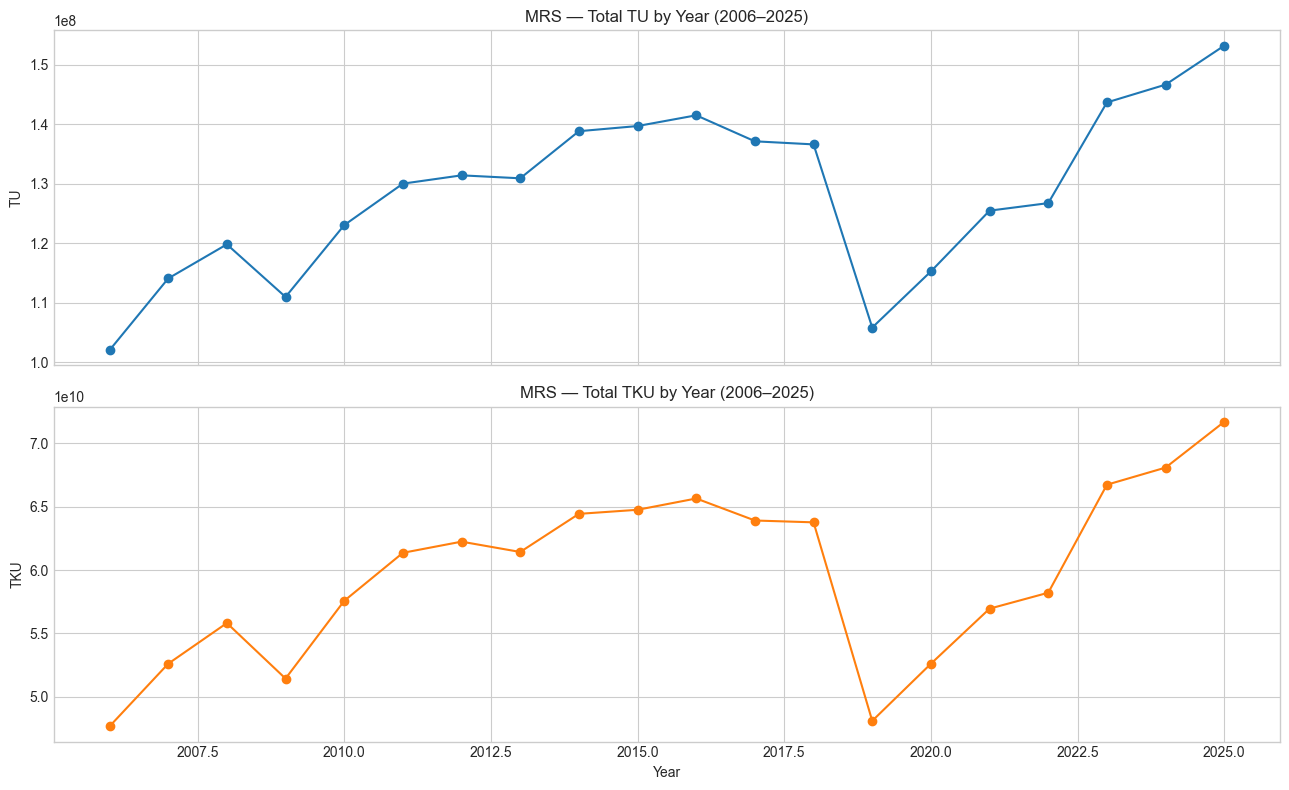

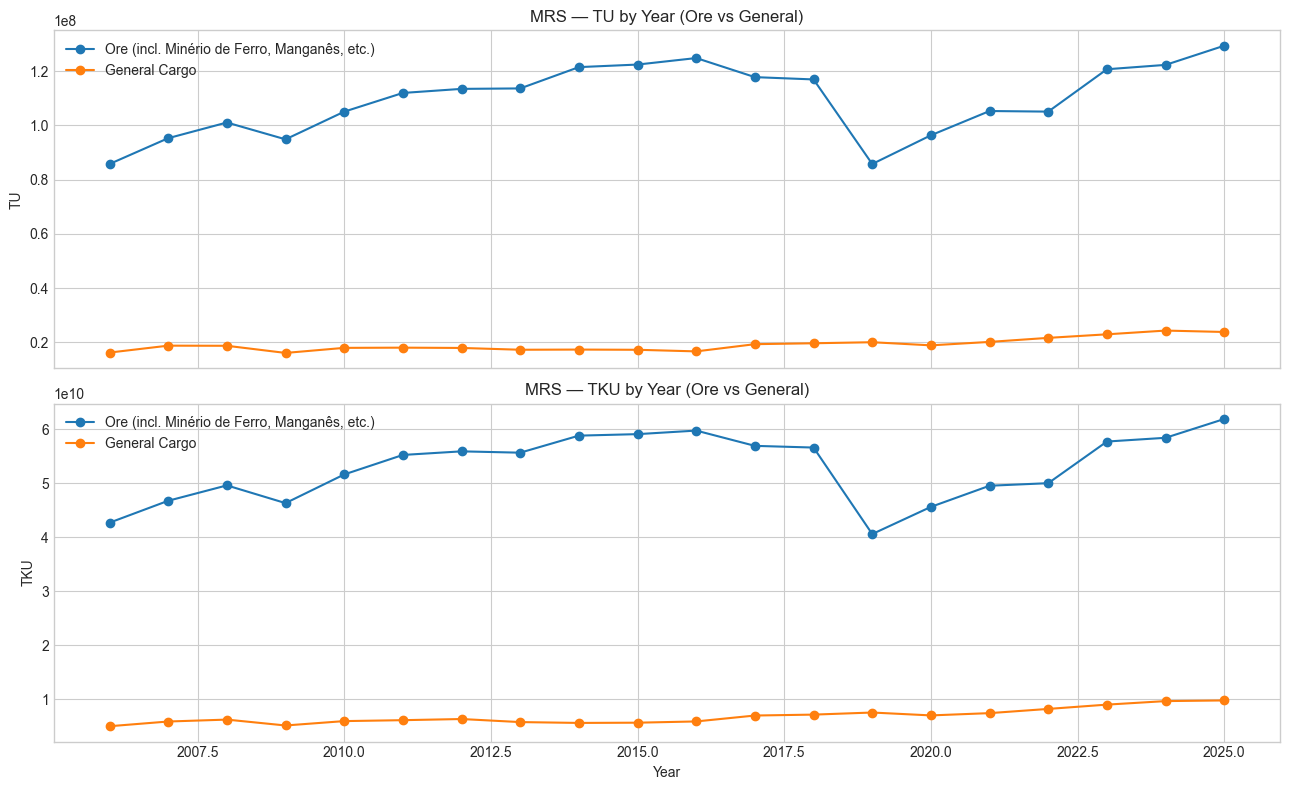

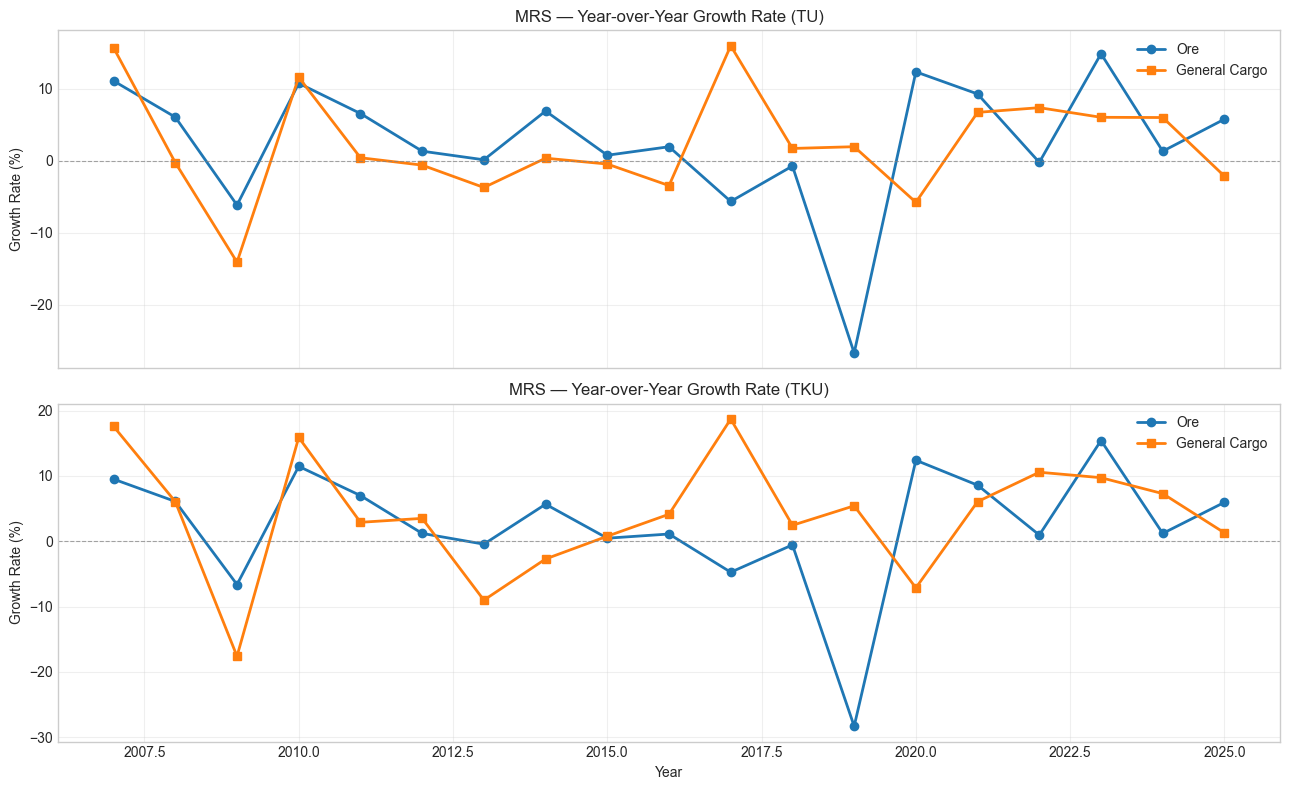


=== YEAR-OVER-YEAR GROWTH RATES (TU) ===


cargo_class,ORE,GENERAL
year,,
2007,11,16
2008,6,-0
2009,-6,-14
2010,11,12
2011,7,0
2012,1,-1
2013,0,-4
2014,7,0
2015,1,-0



=== YEAR-OVER-YEAR GROWTH RATES (TKU) ===


cargo_class,ORE,GENERAL
year,,
2007,10,18
2008,6,6
2009,-7,-18
2010,12,16
2011,7,3
2012,1,4
2013,-0,-9
2014,6,-3
2015,0,1



✅ Done. Edit ORE_KEYWORDS if you want to expand/reduce what counts as Ore.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# SETTINGS (edit if needed)
# =========================
EXCEL_PATH = r"C:\Users\matheus.deoliveira\OneDrive - Wabtec Corporation\Matheus\wabtec\Advanced Technology\MRS\Transporte de Carga - Origem Destino- 2006 - dezembro 2025.xlsx"
TARGET_RAILWAY = "MRS"

# Ore strategy: includes iron ore + manganese + other ore/mineral commodities.
# ✅ You can add/remove items here as you wish.
ORE_KEYWORDS = [
    "Minério de Ferro",
    "Manganês",
    "Bauxita",
    "Cromita",
    "Ilmenita",
    "Cobre",        # optional (mineral)
    "Outros Graneis Minerais",  # optional (if present)
    "Minérios"      # optional (generic)
]

# Plot formatting
plt.style.use("seaborn-v0_8-whitegrid")

# =========================
# 1) READ ALL YEAR SHEETS
# =========================
xls = pd.ExcelFile(EXCEL_PATH, engine="openpyxl")
sheet_names = xls.sheet_names  # expected: 2006..2025

required = ["Mês/Ano", "Ferrovia", "Mercadoria ANTT", "TU", "TKU"]
dfs = []

for sh in sheet_names:
    # Try reading with different header rows (some sheets may have title rows)
    df = None
    for header_row in [0, 1, 2, 3, 4]:
        try:
            df_temp = pd.read_excel(EXCEL_PATH, sheet_name=sh, engine="openpyxl", header=header_row)
            # normalize headers
            df_temp.columns = [str(c).strip() for c in df_temp.columns]
            
            # Check if we have the required columns
            missing = [c for c in required if c not in df_temp.columns]
            if not missing:
                df = df_temp
                if header_row > 0:
                    print(f"Sheet '{sh}': Found headers at row {header_row}")
                break
        except Exception:
            continue
    
    if df is None:
        print(f"⚠️ Warning: Sheet '{sh}' could not be read. Skipping.")
        print(f"   Available columns: {list(pd.read_excel(EXCEL_PATH, sheet_name=sh, engine='openpyxl').columns[:10])}")
        continue

    df = df[required].copy()
    df["sheet"] = sh
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# =========================
# 2) CLEAN + PARSE DATE
# =========================
data["Mês/Ano"] = data["Mês/Ano"].astype(str).str.strip()
data["date"] = pd.to_datetime(data["Mês/Ano"], format="%m/%Y", errors="coerce")

data["TU"] = pd.to_numeric(data["TU"], errors="coerce")
data["TKU"] = pd.to_numeric(data["TKU"], errors="coerce")

data = data.dropna(subset=["date", "TU", "TKU", "Ferrovia", "Mercadoria ANTT"])
data["year"] = data["date"].dt.year

# =========================
# 3) FILTER MRS + CLASSIFY
# =========================
mrs = data[data["Ferrovia"].astype(str).str.strip().str.upper() == TARGET_RAILWAY.upper()].copy()

# Ore if Mercadoria ANTT contains any keyword (case-insensitive)
ore_pattern = "|".join([rf"{k}" for k in ORE_KEYWORDS])
mrs["is_ore"] = mrs["Mercadoria ANTT"].astype(str).str.contains(ore_pattern, case=False, na=False, regex=True)

mrs["cargo_class"] = np.where(mrs["is_ore"], "ORE", "GENERAL")

# =========================
# 4) AGGREGATE BY YEAR
# =========================
# Total MRS per year
mrs_year_total = (
    mrs.groupby("year", as_index=False)[["TU", "TKU"]]
    .sum()
    .sort_values("year")
)

# Split Ore vs General per year
mrs_year_split = (
    mrs.groupby(["year", "cargo_class"], as_index=False)[["TU", "TKU"]]
    .sum()
    .sort_values(["year", "cargo_class"])
)

# Pivot for easier plotting/shares
tu_pivot = mrs_year_split.pivot(index="year", columns="cargo_class", values="TU").fillna(0)
tku_pivot = mrs_year_split.pivot(index="year", columns="cargo_class", values="TKU").fillna(0)

for col in ["ORE", "GENERAL"]:
    if col not in tu_pivot.columns: tu_pivot[col] = 0.0
    if col not in tku_pivot.columns: tku_pivot[col] = 0.0

tu_pivot["TOTAL"] = tu_pivot["ORE"] + tu_pivot["GENERAL"]
tku_pivot["TOTAL"] = tku_pivot["ORE"] + tku_pivot["GENERAL"]

share = pd.DataFrame({
    "year": tu_pivot.index,
    "ore_share_TU_%": np.where(tu_pivot["TOTAL"] > 0, 100 * tu_pivot["ORE"] / tu_pivot["TOTAL"], np.nan),
    "ore_share_TKU_%": np.where(tku_pivot["TOTAL"] > 0, 100 * tku_pivot["ORE"] / tku_pivot["TOTAL"], np.nan),
}).reset_index(drop=True)

# =========================
# 5) OUTPUT TABLES
# =========================
pd.set_option("display.float_format", "{:,.0f}".format)

print("=== MRS: YEARLY TOTALS (TU, TKU) — 2006 to 2025 ===")
display(mrs_year_total)

print("\n=== MRS: YEARLY SPLIT (ORE vs GENERAL) ===")
display(mrs_year_split)

print("\n=== MRS: ORE SHARE (%) BY YEAR ===")
display(share.round(1))

# =========================
# 6) PLOTS
# =========================
years = mrs_year_total["year"].values

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax[0].plot(mrs_year_total["year"], mrs_year_total["TU"], marker="o")
ax[0].set_title("MRS — Total TU by Year (2006–2025)")
ax[0].set_ylabel("TU")

ax[1].plot(mrs_year_total["year"], mrs_year_total["TKU"], marker="o", color="tab:orange")
ax[1].set_title("MRS — Total TKU by Year (2006–2025)")
ax[1].set_ylabel("TKU")
ax[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax[0].plot(tu_pivot.index, tu_pivot["ORE"], marker="o", label="Ore (incl. Minério de Ferro, Manganês, etc.)")
ax[0].plot(tu_pivot.index, tu_pivot["GENERAL"], marker="o", label="General Cargo")
ax[0].set_title("MRS — TU by Year (Ore vs General)")
ax[0].set_ylabel("TU")
ax[0].legend()

ax[1].plot(tku_pivot.index, tku_pivot["ORE"], marker="o", label="Ore (incl. Minério de Ferro, Manganês, etc.)")
ax[1].plot(tku_pivot.index, tku_pivot["GENERAL"], marker="o", label="General Cargo")
ax[1].set_title("MRS — TKU by Year (Ore vs General)")
ax[1].set_ylabel("TKU")
ax[1].set_xlabel("Year")
ax[1].legend()

plt.tight_layout()
plt.show()

# =========================
# 6b) YEAR-OVER-YEAR GROWTH RATES
# =========================
# Calculate percentage change from previous year
tu_growth = tu_pivot[["ORE", "GENERAL"]].pct_change() * 100
tku_growth = tku_pivot[["ORE", "GENERAL"]].pct_change() * 100

# Drop first year (no previous year to compare)
tu_growth = tu_growth.iloc[1:]
tku_growth = tku_growth.iloc[1:]

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# TU Growth
ax[0].plot(tu_growth.index, tu_growth["ORE"], marker="o", label="Ore", linewidth=2)
ax[0].plot(tu_growth.index, tu_growth["GENERAL"], marker="s", label="General Cargo", linewidth=2)
ax[0].axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax[0].set_title("MRS — Year-over-Year Growth Rate (TU)")
ax[0].set_ylabel("Growth Rate (%)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# TKU Growth
ax[1].plot(tku_growth.index, tku_growth["ORE"], marker="o", label="Ore", linewidth=2)
ax[1].plot(tku_growth.index, tku_growth["GENERAL"], marker="s", label="General Cargo", linewidth=2)
ax[1].axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax[1].set_title("MRS — Year-over-Year Growth Rate (TKU)")
ax[1].set_ylabel("Growth Rate (%)")
ax[1].set_xlabel("Year")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== YEAR-OVER-YEAR GROWTH RATES (TU) ===")
display(tu_growth.round(1))

print("\n=== YEAR-OVER-YEAR GROWTH RATES (TKU) ===")
display(tku_growth.round(1))

# =========================
# 7) OPTIONAL: EXPORT RESULTS
# =========================
# Uncomment if you want CSV outputs:
# mrs_year_total.to_csv("mrs_year_total_TU_TKU_2006_2025.csv", index=False, encoding="utf-8-sig")
# mrs_year_split.to_csv("mrs_year_split_ore_general_2006_2025.csv", index=False, encoding="utf-8-sig")
# share.to_csv("mrs_ore_share_2006_2025.csv", index=False, encoding="utf-8-sig")

print("\n✅ Done. Edit ORE_KEYWORDS if you want to expand/reduce what counts as Ore.")